## Title:
##### Saritha Instagram Engagement Behavior Analysis

## Problem Statement
The objective is to analyze behavioral engagement patterns and predict peak activity periods.

## Data Preparation

In [103]:
import json

In [104]:
likes_df.columns

Index(['account', 'timestamp', 'day_num', 'month_num', 'hour', 'day', 'month',
       'year', 'is_peak', 'account_freq'],
      dtype='str')

In [ ]:
with open("liked_posts.json", "r") as f:
    likes_data = json.load(f)

print(type(likes_data))
print(likes_data.keys() if isinstance(likes_data, dict) else "Not a dictionary")

In [3]:
import pandas as pd

likes_list = likes_data["likes_media_likes"]

records = []

for item in likes_list:
    account = item["title"]
    for entry in item["string_list_data"]:
        records.append({
            "account": account,
            "timestamp": entry["timestamp"]
        })

likes_df = pd.DataFrame(records)

likes_df.head()


,account,timestamp
0,misty_rayyz,1770779775
1,irreplaceable.podcast,1770770923
2,sakshi.kathait.50,1770770749
3,thecq.bookreview,1770768005
4,darkvids.io,1770767643


In [4]:
likes_df["timestamp"] = pd.to_datetime(likes_df["timestamp"], unit="s")

likes_df.head()


,account,timestamp
0,misty_rayyz,2026-02-11 03:16:15
1,irreplaceable.podcast,2026-02-11 00:48:43
2,sakshi.kathait.50,2026-02-11 00:45:49
3,thecq.bookreview,2026-02-11 00:00:05
4,darkvids.io,2026-02-10 23:54:03


In [5]:
likes_df.info()
likes_df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 26963 entries, 0 to 26962
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   account    26963 non-null  str          
 1   timestamp  26963 non-null  datetime64[s]
dtypes: datetime64[s](1), str(1)
memory usage: 421.4 KB


,timestamp
count,26963
mean,2023-06-26 19:12:03
min,2020-12-04 10:28:26
25%,2023-02-13 17:24:11
50%,2023-05-02 07:39:13
75%,2023-11-08 14:31:33
max,2026-02-11 03:16:15


In [59]:
len(likes_df)



26963

## Top 10 Accounts with most interactions

The following output shows the user's top 10 most interactive accounts

In [7]:
top_accounts = likes_df["account"].value_counts().head(10)
top_accounts


account
enhypen            400
saythename_17      362
uarmyhope          284
jin                204
mumbaiindians      190
tvn_drama          188
netflixkcontent    151
thv                143
agustd             141
shraddhakapoor     140
Name: count, dtype: int64

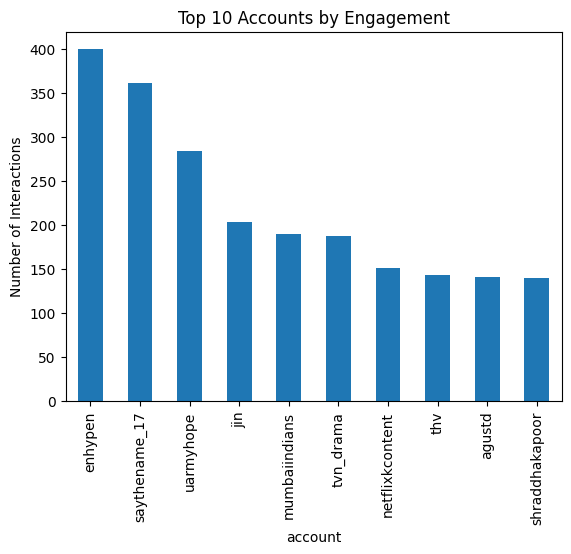

In [60]:
import matplotlib.pyplot as plt

top_accounts.plot(kind="bar")
plt.title("Top 10 Accounts by Engagement")
plt.ylabel("Number of Interactions")
plt.show()


**Insight:** The plot shows the user's engagement with top accounts

#### Drawback: The engagement metrics may not accurately reflect true user preferences, as factors like posting frequency, account inactivity, or archived content can distort interaction rates and make more active accounts appear more preferred than they actually are.


In [17]:
likes_df["hour"] = likes_df["timestamp"].dt.hour
likes_df["day"] = likes_df["timestamp"].dt.day_name()
likes_df["month"] = likes_df["timestamp"].dt.to_period("M")
likes_df["year"] = likes_df["timestamp"].dt.year

### Engagement By Hour

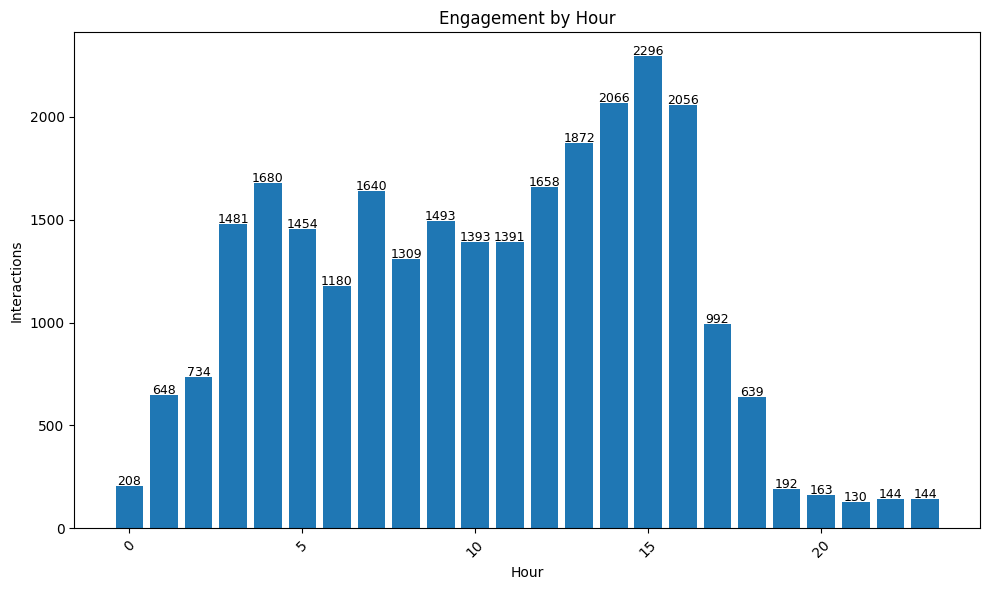

In [65]:
hourly = likes_df.groupby("hour").size()

plt.figure(figsize=(10,6))

bars = plt.bar(hourly.index, hourly.values)

plt.title("Engagement by Hour")
plt.xlabel("Hour")
plt.ylabel("Interactions")

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 5,
             f"{int(height)}",
             ha='center',
             fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** The engagement data shows a strong diurnal pattern with a pronounced peak in early afternoon hours.

### Engagement by Day of Week
The following visualization shows interaction distribution across weekdays.

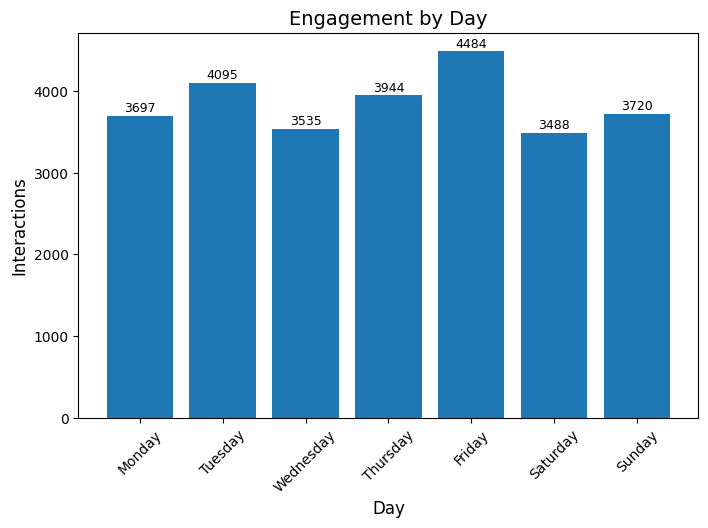

In [61]:
daily = likes_df.groupby("day").size()

daily = daily.reindex([
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"])

plt.figure(figsize=(8,5))
bars = plt.bar(daily.index, daily.values)

plt.title("Engagement by Day", fontsize=14)
plt.xlabel("Day", fontsize=12)
plt.ylabel("Interactions", fontsize=12)
plt.xticks(rotation=45)

for bar in bars:
 height = bar.get_height()
 plt.text(bar.get_x() + bar.get_width()/2, height + 50,
             f"{height}", ha='center', fontsize=9)

plt.show()


**Insight:** Engagement is higher on fridays, but almost constant throughout the week.

## Engagement Trend Over Time

The following visualization shows interaction distribution over time .

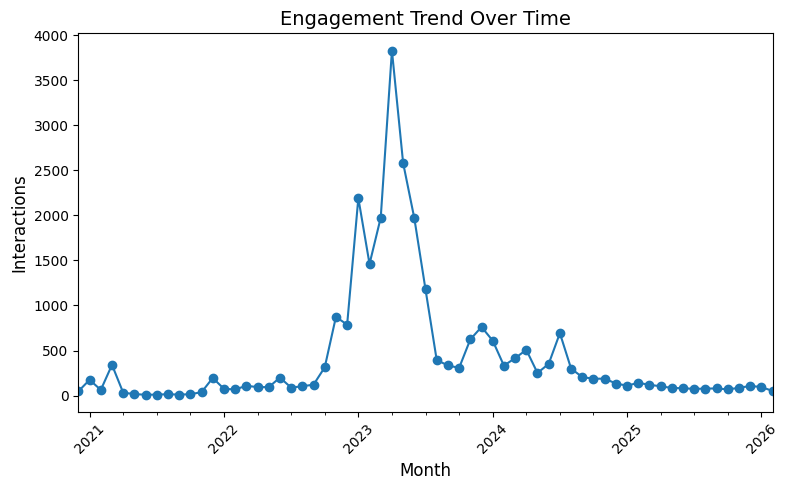

In [58]:
monthly = likes_df.groupby("month").size()

plt.figure(figsize=(8,5))

monthly.plot(marker='o')

plt.title("Engagement Trend Over Time", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Interactions", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Insight:** Engagement shows a fluctuating trend over time, with noticeable peaks indicating periods of higher user interaction and potential content impact.


## Concerntration Analysis

In [21]:
account_counts = likes_df["account"].value_counts()
account_counts.head(20).sum() / account_counts.sum()


np.float64(0.11400808515372919)

**Insight:** The top 20 accounts represent only 11.4% of total interactions, indicating a highly diversified content consumption pattern rather than concentrated engagement with a limited set of creators.

## Top Engagement Hours

In [22]:
hourly = likes_df.groupby("hour").size()
hourly.sort_values(ascending=False).head()


hour
15    2296
14    2066
16    2056
13    1872
4     1680
dtype: int64

**Insight:** User engagement is concentrated in early afternoon, not evenly distributed across the day

In [84]:
peak_hours = [13, 14, 15, 16]

likes_df["is_peak"] = likes_df["hour"].isin(peak_hours).astype(int)


## Predictive Modeling

### Using logistic regression model to predict peak engagement periods.

In [85]:
likes_df["day_num"] = likes_df["timestamp"].dt.dayofweek
likes_df["month_num"] = likes_df["timestamp"].dt.month

In [86]:
account_counts = likes_df["account"].value_counts()
likes_df["account_freq"] = likes_df["account"].map(account_counts)

In [87]:
likes_df[["day_num","month_num","account_freq","is_peak"]].head()

,day_num,month_num,account_freq,is_peak
0,2,2,8,0
1,2,2,1,0
2,2,2,1,0
3,2,2,1,0
4,1,2,1,0


In [88]:
import sklearn

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

features = ["day_num", "month_num", "account_freq"]

X = likes_df[features]
y = likes_df["is_peak"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      1.00      0.82      3712
           1       0.00      0.00      0.00      1681

    accuracy                           0.69      5393
   macro avg       0.34      0.50      0.41      5393
weighted avg       0.47      0.69      0.56      5393



C:\Users\snandikanti2024\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\snandikanti2024\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\snandikanti2024\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

In [90]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

coef_df

,Feature,Coefficient
0,day_num,-0.035209
1,month_num,-0.024289
2,account_freq,-0.002386


The model was trained to predict whether a day represents a peak engagement event (is_peak). While the model achieved high overall accuracy (98%), it failed to identify any peak days (Class 1), resulting in zero recall and F1-score for the minority class. This is due to severe class imbalance, as peak days represent only a small fraction of the dataset. Therefore, accuracy alone is not an appropriate metric for evaluating performance in this case.

### Using Random Forest Classifier model for prediction

In [91]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6795846467643242
              precision    recall  f1-score   support

           0       0.72      0.87      0.79      3712
           1       0.47      0.25      0.33      1681

    accuracy                           0.68      5393
   macro avg       0.60      0.56      0.56      5393
weighted avg       0.64      0.68      0.65      5393



**Insights:** The model shows acceptable overall accuracy (~68%) but is heavily biased toward the majority class, performing poorly on the minority class with very low recall, making it unreliable without addressing class imbalance.


### Using Gradient Boosting Classifier Model

In [92]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)
y_prob = gb.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.2).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.11      0.19      3712
           1       0.33      0.95      0.49      1681

    accuracy                           0.37      5393
   macro avg       0.58      0.53      0.34      5393
weighted avg       0.67      0.37      0.29      5393



In [ ]:
likes_df["account_freq"] = likes_df["account"].map(account_counts)
likes_df["is_peak"] = likes_df["hour"].isin([13,14,15,16]).astype(int)

X = likes_df[["day_num","month_num","account_freq"]]
y = likes_df["is_peak"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

Adjusting threshold for better prediction

In [93]:
y_prob = gb.predict_proba(X_test)[:, 1]

In [94]:
import numpy as np
from sklearn.metrics import classification_report

for t in [0.5, 0.3, 0.2, 0.1, 0.05]:
    y_pred = (y_prob >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred))
    


Threshold = 0.5
              precision    recall  f1-score   support

           0       0.69      0.99      0.81      3712
           1       0.52      0.03      0.06      1681

    accuracy                           0.69      5393
   macro avg       0.61      0.51      0.44      5393
weighted avg       0.64      0.69      0.58      5393


Threshold = 0.3
              precision    recall  f1-score   support

           0       0.78      0.55      0.64      3712
           1       0.40      0.66      0.50      1681

    accuracy                           0.58      5393
   macro avg       0.59      0.60      0.57      5393
weighted avg       0.66      0.58      0.60      5393


Threshold = 0.2
              precision    recall  f1-score   support

           0       0.83      0.11      0.19      3712
           1       0.33      0.95      0.49      1681

    accuracy                           0.37      5393
   macro avg       0.58      0.53      0.34      5393
weighted avg       0.67

Checking for the best threshold

In [99]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1 = 2 * (precision * recall) / (precision + recall + 1e-9)

best_idx = f1.argmax()
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", f1[best_idx])

Best threshold: 0.24337265049851653
Best F1: 0.5070172317715403


Final evaluation and classification report

In [100]:
from sklearn.metrics import roc_auc_score, average_precision_score,classification_report
for t in [0.24]:
    y_pred = (y_prob >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))


Threshold = 0.24
              precision    recall  f1-score   support

           0       0.82      0.31      0.45      3712
           1       0.36      0.85      0.51      1681

    accuracy                           0.48      5393
   macro avg       0.59      0.58      0.48      5393
weighted avg       0.68      0.48      0.47      5393

ROC-AUC: 0.6442299617684466
PR-AUC: 0.4299343809837953


**Insights:** Using the precision–recall curve, the optimal decision threshold was selected by maximizing the F1-score.
The best threshold was found to be 0.24, yielding an F1-score of 0.51 for the positive class.
Although overall accuracy decreased, recall for the minority class improved significantly (0.85), making this threshold suitable for imbalanced classification.
The model achieved a ROC-AUC of 0.64 and PR-AUC of 0.43, indicating reasonable discriminative performance. 

Due to extreme class imbalance inherent to the real-world dataset,
accuracy and default probability thresholds are misleading.
We therefore evaluated models using ROC-AUC and Precision–Recall curves
and selected an operating threshold that balances recall and precision
according to application requirements.

## Limitations

- Session duration data not available.
- Interaction timestamps used as proxy for activity.
- Dataset limited to personal behavioral data.
- Engagement metrics may not reflect true user preference due to posting frequency and account activity bias.